# Hof_popsynth_analysis.ipynb

Data analysis of **population-synthesis sweeps** run with a `run_popsynth*.sh` script
(which launches `run_model_Hof.py` once per parameter combination).

**Generic by design (works for future sweeps with other variables / dimensionality).**
Nothing about *which* parameters were swept is hard-coded here. Everything is recovered
from the two files that actually defined the sweep:

1. **The sweep script `<name>.sh`** is parsed for the grid: every list fed to GNU
   `parallel ... ::: $X_VALUES ::: ...` (or, failing that, the fallback `for v in $X; do`
   loops) and which `run_model_Hof.py --flag "$var"` each list ends up in. Also read
   from it: `CONFIG_FILE`, `OUTDIR` (where the .h5 files are) and `LOGDIR`.
2. **`run_model_Hof.py`** is used for the CLI-flag → config-key mapping (parsed from
   its `overrides = {...}` block and its `config['sec']['key'] = args.flag` lines), for
   `output_filename()` (the single source of truth for filenames), and for
   `make_time_grid()` (the expected final snapshot time).

So a new sweep needs no notebook edits beyond `SWEEP_SCRIPT` below, as long as it keeps
the same pattern: `*_VALUES` lists → `parallel :::` / `for` loops → `--flag "$var"`. A
new `run_model_Hof.py` CLI flag is picked up automatically if it is applied with one of
those two override patterns.

`<name>` throughout = the sweep script's filename without `.sh`
(e.g. `run_popsynth1.00_hof`).

# Imports

In [2]:
# Imports
import os, re, sys, copy, json, itertools
from datetime import datetime

import numpy as np
import pandas as pd
import h5py

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 500)

# Settings

Change `SWEEP_SCRIPT` to analyse a different sweep. The `*_OVERRIDE` switches are only
needed when the paths written in the `.sh` file are not valid on the machine running this
notebook (e.g. working locally on files copied from Nibi); leave them `None` on Nibi.

In [3]:
# ---- which sweep -------------------------------------------------------------------
SWEEP_SCRIPT = "run_popsynth1.00_hof.sh"     # filename of the sweep's .sh launcher (in STARTHERE_DIR)

# ---- where things are --------------------------------------------------------------
# This notebook lives in example/StartHere/notebooks/; the .sh scripts, run_model_Hof.py
# and config/ live one level up. Jupyter's working directory is the notebook's folder.
NOTEBOOK_DIR  = os.path.abspath(os.getcwd())
STARTHERE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
RUN_MODEL     = os.path.join(STARTHERE_DIR, "run_model_Hof.py")   # the model the sweep ran

SWEEP_NAME = os.path.splitext(SWEEP_SCRIPT)[0]   # <name>, e.g. "run_popsynth1.00_hof"

# Optional overrides of the paths read from the .sh file (None = use the .sh value):
OUTDIR_OVERRIDE  = None   # folder holding the sweep's .h5 output files
LOGDIR_OVERRIDE  = None   # parent logs folder; the status CSV goes in <LOGDIR>/<name>/
CONFIG_OVERRIDE  = None   # the sweep's JSON config

# Optional manual grid, bypassing the .sh parser entirely, e.g.
#   {"psi_DW": [0, 10], "e_rad": [0.8, 0.9]}     keys = run_model_Hof.py CLI flag names
# Only needed if a future .sh no longer follows the parsable pattern described above.
SWEEP_GRID_MANUAL = None

# A run counts as having reached the end if its last snapshot time is within this
# RELATIVE tolerance of the last time in the config's time grid (dimensionless).
T_END_RTOL = 1e-3

# run_model_Hof.py (and its disc_setup_Hof import) must be importable for
# output_filename() / make_time_grid():
if STARTHERE_DIR not in sys.path:
    sys.path.insert(0, STARTHERE_DIR)
import run_model_Hof as rmh
from DiscEvolution.constants import yr   # code-time units per year (= 2*pi), see CLAUDE.md

# Helper functions: sweep-script parser, CLI-flag mapping, run status

All the "generic" logic. Read top to bottom:

* `parse_sweep_script()` turns `<name>.sh` into `{flag: [values]}` (+ paths).
* `cli_flag_map()` turns `run_model_Hof.py`'s source into `{flag: (section, key, type)}`.
* `config_for_run()` / `expected_filename()` rebuild one run's config and filename exactly
  as `run_model_Hof.py` did when the sweep launched it.
* `run_status()` opens one .h5 file and classifies it.

**Placeholder `none`:** the sweep scripts use the value `none` to mean "do not pass this
flag at all" (e.g. `ALPHA_SS_LOOP="${ALPHA_SS_VALUES:-none}"`). Such a value is dropped,
and a dimension whose ONLY value is `none` is not a sweep dimension (no CSV column).

In [4]:
# ---------------------------------------------------------------------------
# 1. A minimal bash reader: just enough of bash to recover the sweep grid.
# ---------------------------------------------------------------------------
_BASH_VAR = re.compile(r"\$\{(\w+)(?::-([^}]*))?\}|\$(\w+)")   # ${X}, ${X:-default}, $X

def bash_expand(s, variables):
    """Expand $X / ${X} / ${X:-default} in s using `variables` (unknown -> left as is)."""
    def repl(m):
        name = m.group(1) or m.group(3)
        default = m.group(2)
        val = variables.get(name)
        if val in (None, "") and default is not None:   # ${X:-default}: empty OR unset -> default
            return default
        return val if val is not None else m.group(0)
    return _BASH_VAR.sub(repl, s)


def _strip_comment(line):
    """Drop a full-line or trailing ' # ...' bash comment (no '#' appears inside our quoted values)."""
    if line.lstrip().startswith("#"):
        return ""
    return re.sub(r"\s+#.*$", "", line)


def read_bash_lines(path):
    """Return the script's lines with comments stripped and '\\'-continuations joined."""
    with open(path) as f:
        raw = f.read()
    raw = re.sub(r"\\\n", " ", raw)                     # join "...\<newline>..." continuations
    return [_strip_comment(l) for l in raw.splitlines()]


def bash_toplevel_vars(lines):
    """
    Top-level (UNindented) assignments NAME=value / NAME="value" / NAME='value', in
    script order, each expanded with the variables defined before it. Command
    substitutions ($(...)) are skipped (we never need them, and cannot run them).
    """
    variables = dict(os.environ)    # so e.g. $HOME resolves like it would in bash
    for line in lines:
        m = re.match(r"^([A-Za-z_]\w*)=(.*)$", line)
        if not m:
            continue
        name, rhs = m.group(1), m.group(2).strip()
        if rhs.startswith("$("):
            continue
        if rhs[:1] in ('"', "'"):
            q = rhs[0]
            val = rhs[1:rhs.index(q, 1)] if q in rhs[1:] else rhs[1:]
            if q == '"':
                val = bash_expand(val, variables)       # single quotes: no expansion, as in bash
        else:
            val = bash_expand(rhs.split()[0] if rhs else "", variables)
        variables[name] = val
    return variables


def _function_body(lines, fname):
    """Lines of `fname() { ... }` (up to the first line that is just '}'), or [] if absent."""
    for i, line in enumerate(lines):
        if re.match(rf"^\s*{re.escape(fname)}\s*\(\)\s*\{{", line):
            body = []
            for l in lines[i + 1:]:
                if l.strip() == "}":
                    return body
                body.append(l)
    return []


# ---------------------------------------------------------------------------
# 2. Sweep grid from the .sh file
# ---------------------------------------------------------------------------
def parse_sweep_script(path):
    """
    Parse a run_popsynth*.sh launcher.

    Returns dict with
        variables : all top-level bash variables (expanded strings)
        grid      : {cli_flag: [value strings]} in launch (argument) order, 'none'
                    placeholders removed, dimensions with no real value dropped
        config_file, outdir, logdir : paths as written in the script (may be None)

    How a sweep dimension is recognised (no parameter names are hard-coded):
      * positional lists: `parallel ... run_one {1} {2} ... ::: $A ::: $B ...` -> $1 = A, $2 = B, ...
        (fallback when there is no parallel line: `for v in $A; do` loops + the
         `run_one "$v1" "$v2" ...` call inside them)
      * names: `local x="$1" y="$2"` inside run_one()
      * flags: any `--flag "$x"` inside run_one() (incl. arrays like `args=(--flag "$x")`)
    """
    lines = read_bash_lines(path)
    variables = bash_toplevel_vars(lines)
    split = lambda s: bash_expand(s, variables).split()

    # -- positional argument lists: GNU parallel line first ...
    positional = None                      # list (one per $1, $2, ...) of value-string lists
    for line in lines:
        if re.search(r"\bparallel\b", line) and ":::" in line:
            positional = [split(chunk) for chunk in line.split(":::")[1:]]
            break

    body = _function_body(lines, "run_one")
    locals_ = {}                           # local name -> its values (value-string list)

    if positional is not None:
        for line in body:
            if re.match(r"^\s*local\b", line):
                for name, pos in re.findall(r'(\w+)="?\$\{?(\d+)\}?"?', line):
                    if int(pos) - 1 < len(positional):
                        locals_[name] = positional[int(pos) - 1]
    else:
        # -- ... else the plain for-loop fallback
        loop_vals = {}
        for line in lines:
            for var, lst in re.findall(r"\bfor\s+(\w+)\s+in\s+(.+?);\s*do", line):
                loop_vals[var] = split(lst)
        call = next((l for l in lines if re.match(r'^\s*run_one\s+"', l)), None)
        if call is not None and body:
            call_args = re.findall(r'"\$\{?(\w+)\}?"', call)      # loop vars, in $1, $2, ... order
            positional = [loop_vals.get(v, []) for v in call_args]
            for line in body:
                if re.match(r"^\s*local\b", line):
                    for name, pos in re.findall(r'(\w+)="?\$\{?(\d+)\}?"?', line):
                        if int(pos) - 1 < len(positional):
                            locals_[name] = positional[int(pos) - 1]
        else:
            locals_ = loop_vals           # python called directly inside the loops: flags use loop vars

    # keep locals_ in positional order ($1 first), whatever order the `local` lines list them in
    pos_of = lambda vals: next((i for i, p in enumerate(positional or []) if p is vals), len(locals_))
    locals_ = dict(sorted(locals_.items(), key=lambda kv: pos_of(kv[1])))

    # -- flags: --flag "$var" where var is one of the swept names
    found = {}                                  # flag -> swept variable name
    for line in (body or lines):
        for flag, var in re.findall(r'--(\w+)\s+"?\$\{?(\w+)\}?"?', line):
            if var in locals_ and flag not in found:
                found[flag] = var
    # order the dimensions by launch-argument order ($1, $2, ... / loop nesting order),
    # not by where each --flag happens to appear in the script
    order = list(locals_)
    grid = {}
    for flag in sorted(found, key=lambda fl: order.index(found[fl])):
        vals = [v for v in locals_[found[flag]] if v.lower() != "none"]
        if vals:
            grid[flag] = vals

    return dict(variables=variables, grid=grid,
                config_file=variables.get("CONFIG_FILE"),
                outdir=variables.get("OUTDIR"),
                logdir=variables.get("LOGDIR"))


# ---------------------------------------------------------------------------
# 3. CLI flag -> config key, read from run_model_Hof.py's own source
# ---------------------------------------------------------------------------
_ARGPARSE_TYPES = {"float": float, "int": int, "str": str}

def cli_flag_map(run_model_path):
    """
    {flag: (section, key, python_type)} for every run_model_Hof.py flag that overrides
    a config entry. Recognised source patterns (the two run_model_Hof.py uses):
        ("section", "key"): args.flag,                   (the `overrides` dict)
        config['section']['key'] = args.flag             (e.g. --alpha_SS)
    python_type comes from that flag's `add_argument(..., type=...)` (default float).
    """
    src = open(run_model_path).read()
    types = {f: _ARGPARSE_TYPES.get(t, float)
             for f, t in re.findall(r'add_argument\(\s*"--(\w+)"\s*,\s*type\s*=\s*(\w+)', src)}
    mapping = {}
    for sec, key, flag in re.findall(r'\(\s*"(\w+)"\s*,\s*"(\w+)"\s*\)\s*:\s*args\.(\w+)', src):
        mapping[flag] = (sec, key, types.get(flag, float))
    for sec, key, flag in re.findall(r"config\[['\"](\w+)['\"]\]\[['\"](\w+)['\"]\]\s*=\s*args\.(\w+)", src):
        mapping.setdefault(flag, (sec, key, types.get(flag, float)))
    return mapping


def config_for_run(base_config, params, flag_map):
    """Deep copy of the sweep config with this run's CLI overrides applied, as run_model_Hof.py does."""
    cfg = copy.deepcopy(base_config)
    for flag, value in params.items():
        sec, key, _ = flag_map[flag]
        cfg.setdefault(sec, {})[key] = value
    return cfg


def expected_filename(cfg):
    """Basename of this run's .h5 output: run_model_Hof.output_filename() is the single source of truth."""
    return rmh.output_filename(cfg)


def expected_t_end_Myr(cfg):
    """Last checkpoint time [Myr] the run should reach (make_time_grid() returns code-time units)."""
    return float(np.max(rmh.make_time_grid(cfg["simulation"]))) / (1e6 * yr)


# ---------------------------------------------------------------------------
# 4. Status of one run
# ---------------------------------------------------------------------------
# Status values (CSV column "status"):
#   complete           finished normally and its last snapshot reached the config's final time
#   Mdot_out_of_range  not evolved: initial Mdot outside the valid range (flagged file,
#                      attr Mdot_out_of_range = True, no datasets) -- see run_model_Hof.py
#   crashed            attr complete = True BUT the last snapshot is short of the final time.
#                      NOTE: run_model_Hof.py sets complete = True in a `finally:` block, so an
#                      exception inside _integrate() also leaves complete = True -- the
#                      snapshot-time check is what tells the two apart.
#   incomplete         file exists but attr complete is missing/False: killed before the
#                      `finally:` ran (SLURM time limit, node failure, ...) or still running
#   missing            no output file (never started, or killed before creating it)
#   unreadable         file exists but could not be opened (corrupt, or locked by a writer)
def run_status(path, t_end_Myr, rtol=T_END_RTOL):
    """Return (status, runtime_hr) for the .h5 file at `path`. runtime_hr = run_end - run_start [hours] or NaN."""
    if not os.path.exists(path):
        return "missing", np.nan
    try:
        try:
            f = h5py.File(path, "r", locking=False)   # don't fail on a file a live run holds open
        except TypeError:                              # old h5py without `locking`
            f = h5py.File(path, "r")
    except Exception:
        return "unreadable", np.nan

    with f:
        a = f.attrs
        runtime_hr = np.nan
        if "run_start" in a and "run_end" in a:
            # ISO-8601 local wall-clock times to the second (written by run_model_Hof.py)
            start = datetime.fromisoformat(str(a["run_start"]))
            end   = datetime.fromisoformat(str(a["run_end"]))
            runtime_hr = (end - start).total_seconds() / 3600.0          # [hours]

        if not bool(a.get("complete", False)):
            return "incomplete", runtime_hr
        if bool(a.get("Mdot_out_of_range", False)):
            return "Mdot_out_of_range", runtime_hr
        t_last = float(f["time_snap"][-1]) if ("time_snap" in f and len(f["time_snap"])) else -np.inf  # [Myr]
        if t_last < t_end_Myr * (1.0 - rtol):
            return "crashed", runtime_hr
        return "complete", runtime_hr

# Sweep status table → `<name>_status.csv`

One row per parameter combination in the sweep (the full Cartesian product of the
grid, in the order the `.sh` launched them), **including runs with no output file**.
Columns, in order:

| column | meaning |
|---|---|
| `filename` | expected .h5 basename (from `run_model_Hof.output_filename()`) |
| one column per swept CLI flag | that run's value, named after the `run_model_Hof.py` flag (e.g. `psi_DW` [dimensionless], `alpha_SS` [dimensionless], `M` [Msun], `Rd` [AU], `e_rad` [dimensionless]) |
| `status` | see `run_status()` above |
| `runtime_hr` | wall-clock `run_end - run_start` [hours], incl. calibration/setup; blank when not recorded |

Saved to `<LOGDIR>/<name>/<name>_status.csv` (`LOGDIR` from the `.sh`; the subfolder is
created if needed). Re-running the cell overwrites it with the current status.

In [5]:
# ---- 1. Parse the sweep script and resolve paths ------------------------------------
SWEEP_SCRIPT_PATH = os.path.join(STARTHERE_DIR, SWEEP_SCRIPT)
sweep = parse_sweep_script(SWEEP_SCRIPT_PATH)

def _local_fallback(p):
    """The .sh paths are Nibi paths. If one is under SCRIPT_DIR but does not exist here,
    try the same relative path under this repo's StartHere folder."""
    if p is None or os.path.exists(p):
        return p
    script_dir = sweep["variables"].get("SCRIPT_DIR")
    if script_dir and os.path.abspath(p).startswith(os.path.abspath(script_dir) + os.sep):
        alt = os.path.join(STARTHERE_DIR, os.path.relpath(p, script_dir))
        if os.path.exists(alt):
            return alt
    return p

CONFIG_FILE = CONFIG_OVERRIDE or _local_fallback(sweep["config_file"])
OUTDIR      = OUTDIR_OVERRIDE or sweep["outdir"]
LOGDIR      = LOGDIR_OVERRIDE or sweep["logdir"]
STATUS_DIR  = os.path.join(LOGDIR, SWEEP_NAME)                      # <LOGDIR>/<name>/
STATUS_CSV  = os.path.join(STATUS_DIR, f"{SWEEP_NAME}_status.csv")  # <name>_status.csv

with open(CONFIG_FILE) as f:
    BASE_CONFIG = json.load(f)

# ---- 2. The grid: {flag: [typed values]} ---------------------------------------------
FLAG_MAP = cli_flag_map(RUN_MODEL)
grid_str = SWEEP_GRID_MANUAL if SWEEP_GRID_MANUAL is not None else sweep["grid"]
unknown = [fl for fl in grid_str if fl not in FLAG_MAP]
if unknown:
    raise KeyError(f"Swept flag(s) {unknown} not found as config overrides in {RUN_MODEL}. "
                   f"Known flags: {sorted(FLAG_MAP)}")
# cast with the flag's argparse type, exactly as run_model_Hof.py receives it
# (e.g. "0" -> 0.0, so the filename token is "psi0.0" like the real file)
GRID = {fl: [FLAG_MAP[fl][2](v) for v in vals] for fl, vals in grid_str.items()}
SWEEP_PARAMS = list(GRID)        # column order = launch-argument order

print(f"Sweep script : {SWEEP_SCRIPT_PATH}")
print(f"Config       : {CONFIG_FILE}")
print(f"Output dir   : {OUTDIR}")
print(f"Status CSV   : {STATUS_CSV}")
print(f"Grid ({' x '.join(str(len(v)) for v in GRID.values())} = "
      f"{int(np.prod([len(v) for v in GRID.values()]))} runs):")
for fl, vals in GRID.items():
    sec, key, _ = FLAG_MAP[fl]
    print(f"  --{fl:<10s} -> {sec}.{key:<10s} {vals}")

# ---- 3. One row per combination ------------------------------------------------------
rows = []
for combo in itertools.product(*GRID.values()):
    params = dict(zip(SWEEP_PARAMS, combo))
    cfg = config_for_run(BASE_CONFIG, params, FLAG_MAP)
    fname = expected_filename(cfg)
    status, runtime_hr = run_status(os.path.join(OUTDIR, fname), expected_t_end_Myr(cfg))
    rows.append({"filename": fname, **params, "status": status, "runtime_hr": runtime_hr})

status_df = pd.DataFrame(rows, columns=["filename", *SWEEP_PARAMS, "status", "runtime_hr"])

# Sanity check: .h5 files in OUTDIR that the grid did NOT predict usually mean the
# filename format or the grid parsing is off (or leftovers from another sweep).
if os.path.isdir(OUTDIR):
    unexpected = sorted(set(f for f in os.listdir(OUTDIR) if f.endswith(".h5")) - set(status_df["filename"]))
    if unexpected:
        print(f"\nWARNING: {len(unexpected)} .h5 file(s) in OUTDIR not predicted by the grid, e.g.:")
        for f in unexpected[:5]:
            print("   ", f)
else:
    print(f"\nWARNING: OUTDIR does not exist here ({OUTDIR}) -- every run will show as 'missing'. "
          f"Set OUTDIR_OVERRIDE if the files are elsewhere.")

# ---- 4. Save and summarise -----------------------------------------------------------
os.makedirs(STATUS_DIR, exist_ok=True)
status_df.to_csv(STATUS_CSV, index=False)
print(f"\nWrote {len(status_df)} rows -> {STATUS_CSV}\n")
print(status_df["status"].value_counts().to_string())
rt = status_df.loc[status_df["status"] == "complete", "runtime_hr"]
if rt.notna().any():
    print(f"\nRuntime of complete runs [hours]: median {rt.median():.2f}, max {rt.max():.2f}")
status_df

Sweep script : /project/6000781/imontesd/DiscEvolution/example/StartHere/run_popsynth1.00_hof.sh
Config       : /home/imontesd/projects/def-mbalogh/imontesd/DiscEvolution/example/StartHere/config/popsynth/DiscConfig_Hof_popsynth1.00.json
Output dir   : /project/def-mbalogh/imontesd/output/DiscEvolution/popsynth/1.00
Status CSV   : /project/def-mbalogh/imontesd/output/DiscEvolution/logs/run_popsynth1.00_hof/run_popsynth1.00_hof_status.csv
Grid (4 x 3 x 3 x 3 x 3 = 324 runs):
  --psi_DW     -> winds.psi_DW     [0.0, 10.0, 100.0, 1000.0]
  --alpha_SS   -> calibration.alpha_SS   [0.0001, 0.001, 0.01]
  --M          -> disc.M          [0.001, 0.01, 0.1]
  --Rd         -> disc.Rd         [25.0, 50.0, 100.0]
  --e_rad      -> winds.e_rad      [0.8, 0.9, 1.0]

Wrote 324 rows -> /project/def-mbalogh/imontesd/output/DiscEvolution/logs/run_popsynth1.00_hof/run_popsynth1.00_hof_status.csv

status
complete             201
Mdot_out_of_range    114
crashed                9

Runtime of complete runs [

,filename,psi_DW,alpha_SS,M,Rd,e_rad,status,runtime_hr
0,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd2.5e+01.h5,0.0,0.0001,0.001,25.0,0.8,Mdot_out_of_range,0.000278
1,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.9_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd2.5e+01.h5,0.0,0.0001,0.001,25.0,0.9,Mdot_out_of_range,0.000556
2,hof_discwind_popsynth1.00_gamma1_psi0.0_erad1.0_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd2.5e+01.h5,0.0,0.0001,0.001,25.0,1.0,Mdot_out_of_range,0.000833
3,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd5.0e+01.h5,0.0,0.0001,0.001,50.0,0.8,Mdot_out_of_range,0.000278
4,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.9_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd5.0e+01.h5,0.0,0.0001,0.001,50.0,0.9,Mdot_out_of_range,0.000556
5,hof_discwind_popsynth1.00_gamma1_psi0.0_erad1.0_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd5.0e+01.h5,0.0,0.0001,0.001,50.0,1.0,Mdot_out_of_range,0.000278
6,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd1.0e+02.h5,0.0,0.0001,0.001,100.0,0.8,Mdot_out_of_range,0.000278
7,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.9_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd1.0e+02.h5,0.0,0.0001,0.001,100.0,0.9,Mdot_out_of_range,0.000833
8,hof_discwind_popsynth1.00_gamma1_psi0.0_erad1.0_aSS1.0e-04_Mdot1.0e-08_M1.0e-03_Rd1.0e+02.h5,0.0,0.0001,0.001,100.0,1.0,Mdot_out_of_range,0.000556
9,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd2.5e+01.h5,0.0,0.0001,0.010,25.0,0.8,complete,0.458889


# Per-run summary table → `<name>_summary.csv`

Collapses each run's time evolution into a few **scalar observables**, one row per run
(the sweep parameters + one column per observable). It is the input for the
sensitivity ranking below, and later for the heatmaps / wind-effect plots.

Only runs with `status == "complete"` in `status_df` are summarised (out-of-range,
crashed, incomplete and missing runs have no full evolution to summarise).

**Observables (edit `OBSERVABLES` to add or remove any):** each is a small function of
one run's HDF5 data, so a new one is a few lines and needs no other changes.

| column | definition | units |
|---|---|---|
| `t_50 [Myr]`, `t_90 [Myr]` | first time `disk_Mass` falls to 50% / 10% of its initial value; NaN if never reached by the end of the run (**censored**, so dropped from the fit) | Myr |
| `Mdot_star@<age> [Msun/yr]` | `disk_Mdot_star` (inner-boundary accretion rate) at `SUMMARY_AGE_MYR` | M☉/yr |
| `Mdisc/M0@<age>` | `disk_Mass(age) / disk_Mass(0)`: fraction of the disc left | dimensionless |
| `tau@<age> [Myr]` | `disk_Mass / disk_Mdot_star` at that age: the "disc age" observers infer | Myr |
| `R50@<age> [AU]` | radius enclosing half the **gas** mass (from `Sigma_G` at the snapshot nearest that age) | AU |

`disk_Mass` is `disc.Mtot()`, which integrates the **total** (gas + dust) Σ, i.e. ~99% gas
for d2g = 0.01. Units per CLAUDE.md: `t` [yr], `time_snap` [Myr], `disk_Mass` [g],
`disk_Mdot_star` [M☉/yr], `Sigma_G` [g cm⁻²], `R` [AU].

**Run time:** each file's `t` / `disk_Mass` series has one entry per 5 simulation steps (up
to ~10⁶ entries), stored in small chunks, so reading a whole sweep from `/project` takes
minutes. Run this on a compute node (`salloc` / JupyterLab session), not a login node.
(2026-10-09) To keep it fast and safe:
* **Progress:** a line every `PROGRESS_EVERY` files with files read, elapsed time and an ETA.
* **Checkpointing:** the partial table is written to `SUMMARY_CSV` every `SAVE_EVERY` files,
  and again if the cell is interrupted (Kernel → Interrupt). Re-running the cell **resumes**:
  runs already in the CSV are not read again.
* **Less I/O:** only the ≤ 2 `disk_Mdot_star` entries around `SUMMARY_AGE_MYR` are read, not
  the whole series (`t` and `disk_Mass` are still read whole, for `t_50` / `t_90`).

**Caching:** the table is saved next to the status CSV. Re-running the cell only reads
runs not already in it (e.g. runs that completed since). Set `REGENERATE_SUMMARY = True`
after changing an observable's definition, to recompute every row.

In [6]:
# ---- settings ------------------------------------------------------------------------
SUMMARY_AGE_MYR    = 1.0     # [Myr] age at which the "@<age>" observables are evaluated
REGENERATE_SUMMARY = False   # True -> ignore the cached CSV and recompute every row
SUMMARY_CSV = os.path.join(STATUS_DIR, f"{SWEEP_NAME}_summary.csv")   # <LOGDIR>/<name>/<name>_summary.csv
# (2026-10-09) progress / checkpointing, so a long read over /project never looks frozen
# and an interrupted cell (kernel restart, lost connection, ...) loses at most one batch:
PROGRESS_EVERY = 20          # print a progress line every this many files read
SAVE_EVERY     = 20          # write the partial table to SUMMARY_CSV every this many files read
                             # (re-running the cell then resumes: runs already in the CSV are skipped)


def read_run(path):
    """
    Read only what the observables need from one .h5 file. Returns dict of numpy arrays:
        t [yr], Mdisc [g]                  -- FULL dense scalar time series (one entry per `t`);
                                              needed whole for t_50 / t_90 (first crossing)
        t_win [yr], Mdot_win [Msun/yr]     -- (2026-10-09) only the <= 2 `disk_Mdot_star` entries
                                              bracketing SUMMARY_AGE_MYR, not the whole series:
                                              the only Mdot observable is its value at that age
        time_snap [Myr], R [AU], Sigma_G_age [g/cm^2]
                                           -- profile at the snapshot nearest SUMMARY_AGE_MYR
                                              (one row of Sigma_G, not the whole array)
    `t`, `disk_Mass` and `disk_Mdot_star` are written together in run_model_Hof.py, so they
    share one index.
    """
    with h5py.File(path, "r", locking=False) as f:
        time_snap = f["time_snap"][:]                              # [Myr]
        i_age = int(np.argmin(np.abs(time_snap - SUMMARY_AGE_MYR)))
        t = f["t"][:]                                              # [yr]
        # indices bracketing the age: t[j-1] < age <= t[j]; slice clipped to [0, len(t))
        j = int(np.searchsorted(t, SUMMARY_AGE_MYR * 1e6))
        lo, hi = max(j - 1, 0), min(j + 1, len(t))
        return dict(
            t=t,                                                   # [yr]
            Mdisc=f["disk_Mass"][:],                               # [g]
            t_win=t[lo:hi],                                        # [yr]
            Mdot_win=f["disk_Mdot_star"][lo:hi],                   # [Msun/yr]
            time_snap=time_snap,                                   # [Myr]
            t_snap_age=float(time_snap[i_age]),                    # [Myr] snapshot actually used
            R=f["R"][:],                                           # [AU]
            Sigma_G_age=f["Sigma_G"][i_age],                       # [g/cm^2]
        )


def time_to_fraction(run, frac):
    """First time [Myr] at which Mdisc/Mdisc(0) <= frac, linearly interpolated between
    outputs; NaN if the run never gets there (censored: the disc outlived the run)."""
    m = run["Mdisc"] / run["Mdisc"][0]                             # dimensionless
    below = np.nonzero(m <= frac)[0]
    if len(below) == 0:
        return np.nan
    j = below[0]
    if j == 0:
        return run["t"][0] / 1e6
    # interpolate t between the last output above and the first output at/below frac
    t_cross = np.interp(frac, [m[j], m[j - 1]], [run["t"][j], run["t"][j - 1]])   # [yr]
    return t_cross / 1e6                                                          # [Myr]


def value_at_age(run, key, t_key="t"):
    """Time series run[key] (sampled at run[t_key], [yr]) interpolated to SUMMARY_AGE_MYR;
    NaN outside the run. (2026-10-09) t_key added so the 2-point Mdot window can be used."""
    if len(run[t_key]) == 0:
        return np.nan
    return float(np.interp(SUMMARY_AGE_MYR * 1e6, run[t_key], run[key], left=np.nan, right=np.nan))


def half_mass_radius(R, Sigma):
    """Radius [AU] enclosing half of the mass of the profile Sigma(R) (any units of Sigma):
    cumulative M(<R) = integral 2 pi R Sigma dR (trapezoid), then interpolate to M_tot/2."""
    dM = np.pi * (R[1:] + R[:-1]) * (Sigma[1:] + Sigma[:-1]) / 2 * np.diff(R)   # 2 pi R_mid Sigma_mid dR
    M_enc = np.concatenate([[0.0], np.cumsum(dM)])
    if M_enc[-1] <= 0:
        return np.nan
    return float(np.interp(0.5 * M_enc[-1], M_enc, R))


_age = f"{SUMMARY_AGE_MYR:g}Myr"
# column name -> function(run) -> scalar. Add a line here to add an observable.
# (If a new observable needs another FULL time series, read it in read_run() too.)
OBSERVABLES = {
    "t_50 [Myr]":                lambda r: time_to_fraction(r, 0.5),
    "t_90 [Myr]":                lambda r: time_to_fraction(r, 0.1),
    f"Mdot_star@{_age} [Msun/yr]": lambda r: value_at_age(r, "Mdot_win", "t_win"),
    f"Mdisc/M0@{_age}":          lambda r: value_at_age(r, "Mdisc") / r["Mdisc"][0],
    # tau = M_disc / Mdot: [g] / Msun -> [Msun]; / [Msun/yr] -> [yr]; / 1e6 -> [Myr]
    f"tau@{_age} [Myr]":         lambda r: (value_at_age(r, "Mdisc") / Msun
                                            / value_at_age(r, "Mdot_win", "t_win") / 1e6),
    f"R50@{_age} [AU]":          lambda r: half_mass_radius(r["R"], r["Sigma_G_age"]),
}


# ---- build / update the table --------------------------------------------------------
from DiscEvolution.constants import Msun          # [g]
import time

SUMMARY_COLS = ["filename", *SWEEP_PARAMS, *OBSERVABLES]

def assemble_summary(cached, new_rows):
    """cached table (or None) + newly computed rows -> one DataFrame with SUMMARY_COLS."""
    parts = [d for d in (cached, pd.DataFrame(new_rows)) if d is not None and len(d)]
    return pd.concat(parts, ignore_index=True)[SUMMARY_COLS] if parts else pd.DataFrame(columns=SUMMARY_COLS)

cached = None
if os.path.exists(SUMMARY_CSV) and not REGENERATE_SUMMARY:
    cached = pd.read_csv(SUMMARY_CSV)
    # a changed observable list or sweep grid invalidates the cache
    if list(cached.columns) != SUMMARY_COLS:
        print("Cached summary has different columns -> recomputing every row.")
        cached = None

done = set(cached["filename"]) if cached is not None else set()
todo = status_df[(status_df["status"] == "complete") & ~status_df["filename"].isin(done)]
os.makedirs(STATUS_DIR, exist_ok=True)
print(f"{len(done)} run(s) already in {SUMMARY_CSV}; {len(todo)} to read.", flush=True)

new_rows, failed = [], []
t_start = time.time()                            # [s] wall clock, for progress / ETA
try:
    for k, (_, row) in enumerate(todo.iterrows(), start=1):
        try:
            run = read_run(os.path.join(OUTDIR, row["filename"]))
            if abs(run["t_snap_age"] - SUMMARY_AGE_MYR) > 1e-6:
                print(f"note: {row['filename']}: no snapshot at {SUMMARY_AGE_MYR} Myr, "
                      f"R50 uses t = {run['t_snap_age']} Myr")
            obs = {name: float(fn(run)) for name, fn in OBSERVABLES.items()}
            new_rows.append({"filename": row["filename"], **{p: row[p] for p in SWEEP_PARAMS}, **obs})
        except Exception as e:                   # one bad file must not stop the table
            failed.append((row["filename"], f"{type(e).__name__}: {e}"))

        if k % PROGRESS_EVERY == 0 or k == len(todo):
            elapsed = time.time() - t_start                      # [s]
            eta = elapsed / k * (len(todo) - k)                  # [s], assumes constant time per file
            print(f"  {k:>4d}/{len(todo)} read  ({elapsed/60:5.1f} min elapsed, "
                  f"~{eta/60:5.1f} min left, {len(failed)} failed)", flush=True)
        if k % SAVE_EVERY == 0:
            # checkpoint: cached + rows so far (unfiltered; the final save below re-orders/filters)
            assemble_summary(cached, new_rows).to_csv(SUMMARY_CSV, index=False)
finally:
    # also runs on an interrupt (Kernel -> Interrupt): keep every row computed so far
    if new_rows:
        assemble_summary(cached, new_rows).to_csv(SUMMARY_CSV, index=False)

# keep only runs that are (still) complete, in the status table's (launch) order
summary_df = (status_df.loc[status_df["status"] == "complete", ["filename"]]
              .merge(assemble_summary(cached, new_rows), on="filename", how="inner"))
summary_df.to_csv(SUMMARY_CSV, index=False)
print(f"{len(new_rows)} run(s) read, {len(done)} from cache -> {len(summary_df)} rows -> {SUMMARY_CSV}")
for fn, err in failed:
    print(f"FAILED {fn}: {err}")
# NaN counts per observable (t_50 / t_90 NaN = disc outlived the run, i.e. censored)
print("\nNaN per observable:\n" + summary_df[list(OBSERVABLES)].isna().sum().to_string())
summary_df

201 run(s) already in /project/def-mbalogh/imontesd/output/DiscEvolution/logs/run_popsynth1.00_hof/run_popsynth1.00_hof_summary.csv; 0 to read.
0 run(s) read, 201 from cache -> 201 rows -> /project/def-mbalogh/imontesd/output/DiscEvolution/logs/run_popsynth1.00_hof/run_popsynth1.00_hof_summary.csv

NaN per observable:
t_50 [Myr]                   59
t_90 [Myr]                  102
Mdot_star@1Myr [Msun/yr]      0
Mdisc/M0@1Myr                 0
tau@1Myr [Myr]                0
R50@1Myr [AU]                 0


,filename,psi_DW,alpha_SS,M,Rd,e_rad,t_50 [Myr],t_90 [Myr],Mdot_star@1Myr [Msun/yr],Mdisc/M0@1Myr,tau@1Myr [Myr],R50@1Myr [AU]
0,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd2.5e+01.h5,0.0,0.0001,0.010,25.0,0.8,NaN,NaN,1.766955e-10,9.758666e-01,55.228575,18.171170
1,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.9_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd2.5e+01.h5,0.0,0.0001,0.010,25.0,0.9,NaN,NaN,1.777572e-10,9.755087e-01,54.878583,18.180679
2,hof_discwind_popsynth1.00_gamma1_psi0.0_erad1.0_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd2.5e+01.h5,0.0,0.0001,0.010,25.0,1.0,NaN,NaN,1.766269e-10,9.751708e-01,55.210639,18.189567
3,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd1.0e+02.h5,0.0,0.0001,0.010,100.0,0.8,NaN,NaN,4.294592e-11,9.951018e-01,231.710340,69.799488
4,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.9_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd1.0e+02.h5,0.0,0.0001,0.010,100.0,0.9,NaN,NaN,4.302981e-11,9.950712e-01,231.251487,69.802568
5,hof_discwind_popsynth1.00_gamma1_psi0.0_erad1.0_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd1.0e+02.h5,0.0,0.0001,0.010,100.0,1.0,NaN,NaN,4.311037e-11,9.950421e-01,230.812609,69.805506
6,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-01_Rd2.5e+01.h5,0.0,0.0001,0.100,25.0,0.8,NaN,NaN,2.815884e-09,9.491694e-01,33.707615,18.912643
7,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.9_aSS1.0e-04_Mdot1.0e-08_M1.0e-01_Rd2.5e+01.h5,0.0,0.0001,0.100,25.0,0.9,NaN,NaN,2.868069e-09,9.481045e-01,33.057165,18.945019
8,hof_discwind_popsynth1.00_gamma1_psi0.0_erad1.0_aSS1.0e-04_Mdot1.0e-08_M1.0e-01_Rd2.5e+01.h5,0.0,0.0001,0.100,25.0,1.0,NaN,NaN,2.911035e-09,9.471365e-01,32.536000,18.974741
9,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5,0.0,0.0001,0.100,50.0,0.8,NaN,NaN,1.284140e-09,9.791583e-01,76.250034,35.888582


# Figure 1: sensitivity ranking — which sweep parameters control each observable?

For every observable Y, one least-squares fit over all summarised runs:

$$\log_{10} Y = c + \sum_p \beta_p\, x_p ,$$

where $x_p$ is sweep parameter $p$ after a transform chosen automatically from its sampled
values (override with `PARAM_TRANSFORMS`):

* `log`: $x = \log_{10} p$, if all values > 0 and max/min ≥ `LOG_SPAN_MIN` (= 3, i.e.
  ≳ 0.5 decade; here α_SS, M, and Rd = 25–100 AU). Then β is a **power-law exponent**: Y ∝ p^β.
* `log1p`: $x = \log_{10}(1+p)$, if the values include 0 but the positive ones span
  max/min ≥ `LOG_SPAN_MIN` (here ψ_DW: ψ = 0 is the pure-viscous case, where log ψ is undefined).
* `linear`: $x = p$ otherwise (here e_rad, 0.8–1.0: max/min = 1.25).

Parameters with a single value in the sweep are dropped (nothing to fit).

**Plotted quantity:** the β's are not comparable as they stand (M spans 2 decades,
e_rad 0.2 linearly), so each bar is the **effect across the sampled range**

$$\Delta \log_{10} Y = \beta_p\,(x_{p,\max} - x_{p,\min}),$$

i.e. how many decades Y changes going from the lowest to the highest sampled value of p
with everything else fixed. ±1 = a factor of 10. Error bars = ±1 standard error of β
times the same range. **R²** (printed next to each observable) says how well a pure
power law in all parameters describes the sweep. A low R² means the parameters
**interact** (e.g. the ψ effect depends on α_SS); the bars are then averages over the
grid, and the heatmaps / wind-effect ratios are needed to see the detail. One known
interaction is built in: e_rad has no effect at ψ = 0, so β_e_rad averages that
"zero" with its effect at ψ > 0.

**Expected values as a check:** for a viscous-like disc, timescales go as
t_visc ∝ R_d / α, so for `t_50` / `t_90` / `tau` expect β_alpha_SS ≈ −1, β_Rd ≈ +1, β_M ≈ 0.

In [7]:
# ---- settings ------------------------------------------------------------------------
# Force a transform for a parameter, e.g. {"e_rad": "linear", "psi_DW": "log1p"}.
# Parameters not listed get the automatic choice described above.
PARAM_TRANSFORMS = {}
# Observables to fit (default: all of OBSERVABLES), in plotting order (top to bottom).
FIT_OBSERVABLES = list(OBSERVABLES)
MIN_RUNS_FOR_FIT = 10        # skip an observable with fewer usable runs than this
LOG_SPAN_MIN = 3.0          # [dimensionless] max/min ratio above which a positive parameter is fit in log10

_TRANSFORM_FUNCS = {"log": np.log10, "log1p": lambda v: np.log10(1.0 + v), "linear": lambda v: v}
_TRANSFORM_LABELS = {"log": "log₁₀ {p}", "log1p": "log₁₀(1+{p})", "linear": "{p}"}


def auto_transform(values):
    """'log' / 'log1p' / 'linear' for one parameter's sampled values (see markdown above)."""
    v = np.unique(np.asarray(values, dtype=float))
    pos = v[v > 0]
    spans = len(pos) >= 2 and pos.max() / pos.min() >= LOG_SPAN_MIN   # wide enough for a power law
    if spans and np.all(v > 0):
        return "log"
    if spans and np.all(v >= 0):
        return "log1p"
    return "linear"


def sensitivity_fit(df, params, observables, transforms=None, min_runs=MIN_RUNS_FOR_FIT):
    """
    Fit log10 Y = c + sum_p beta_p * x_p for each observable Y (ordinary least squares).

    Returns (fit_df, transforms):
      fit_df    : one row per (observable, parameter) with
                  beta, beta_se                        -- coefficient and its 1-sigma standard error
                  x_range                              -- x_max - x_min of the transformed parameter
                  effect = beta * x_range, effect_se   -- [decades of Y] across the sampled range
                  R2, N                                -- fit quality, runs used for that observable
      transforms: {param: transform name} actually used
    Rows where Y is NaN, <= 0 (log undefined) or infinite are dropped per observable.
    """
    transforms = dict(transforms or {})
    # parameters that actually vary among the summarised runs
    varying = [p for p in params if df[p].nunique() > 1]
    for p in varying:
        transforms.setdefault(p, auto_transform(df[p]))
    X_all = np.column_stack([_TRANSFORM_FUNCS[transforms[p]](df[p].to_numpy(float)) for p in varying])
    x_range = X_all.max(axis=0) - X_all.min(axis=0)

    out = []
    for obs in observables:
        y = df[obs].to_numpy(float)
        ok = np.isfinite(y) & (y > 0)
        N = int(ok.sum())
        if N < max(min_runs, len(varying) + 2):
            print(f"skip {obs!r}: only {N} usable runs")
            continue
        X = np.column_stack([np.ones(N), X_all[ok]])            # [intercept, x_1, ..., x_k]
        ly = np.log10(y[ok])
        coef, *_ = np.linalg.lstsq(X, ly, rcond=None)
        resid = ly - X @ coef
        dof = N - X.shape[1]
        sigma2 = resid @ resid / dof                             # residual variance [decades^2]
        se = np.sqrt(np.diag(sigma2 * np.linalg.pinv(X.T @ X)))  # 1-sigma standard errors
        ss_tot = np.sum((ly - ly.mean()) ** 2)
        R2 = 1.0 - (resid @ resid) / ss_tot if ss_tot > 0 else np.nan
        for k, p in enumerate(varying):
            out.append(dict(observable=obs, param=p, transform=transforms[p],
                            beta=coef[k + 1], beta_se=se[k + 1], x_range=x_range[k],
                            effect=coef[k + 1] * x_range[k], effect_se=se[k + 1] * x_range[k],
                            R2=R2, N=N))
    return pd.DataFrame(out), transforms


fit_df, USED_TRANSFORMS = sensitivity_fit(summary_df, SWEEP_PARAMS, FIT_OBSERVABLES, PARAM_TRANSFORMS)
print("Transforms used:", USED_TRANSFORMS)

# Table view of the figure (the exact numbers behind every bar)
fit_df.pivot(index="observable", columns="param", values="effect").reindex(
    index=[o for o in FIT_OBSERVABLES if o in set(fit_df["observable"])],
    columns=[p for p in SWEEP_PARAMS if p in USED_TRANSFORMS]).round(2)

Transforms used: {'psi_DW': 'log1p', 'alpha_SS': 'log', 'M': 'log', 'Rd': 'log', 'e_rad': 'linear'}


param,psi_DW,alpha_SS,M,Rd,e_rad
observable,,,,,
t_50 [Myr],-3.27,-2.01,-0.09,0.60,0.10
t_90 [Myr],-3.13,-2.01,-0.01,0.54,0.08
Mdot_star@1Myr [Msun/yr],-18.54,-16.23,4.38,2.06,0.51
Mdisc/M0@1Myr,-21.58,-17.94,2.40,2.49,0.19
tau@1Myr [Myr],-3.04,-1.71,0.01,0.43,-0.32
R50@1Myr [AU],-0.33,0.24,0.06,0.42,-0.05


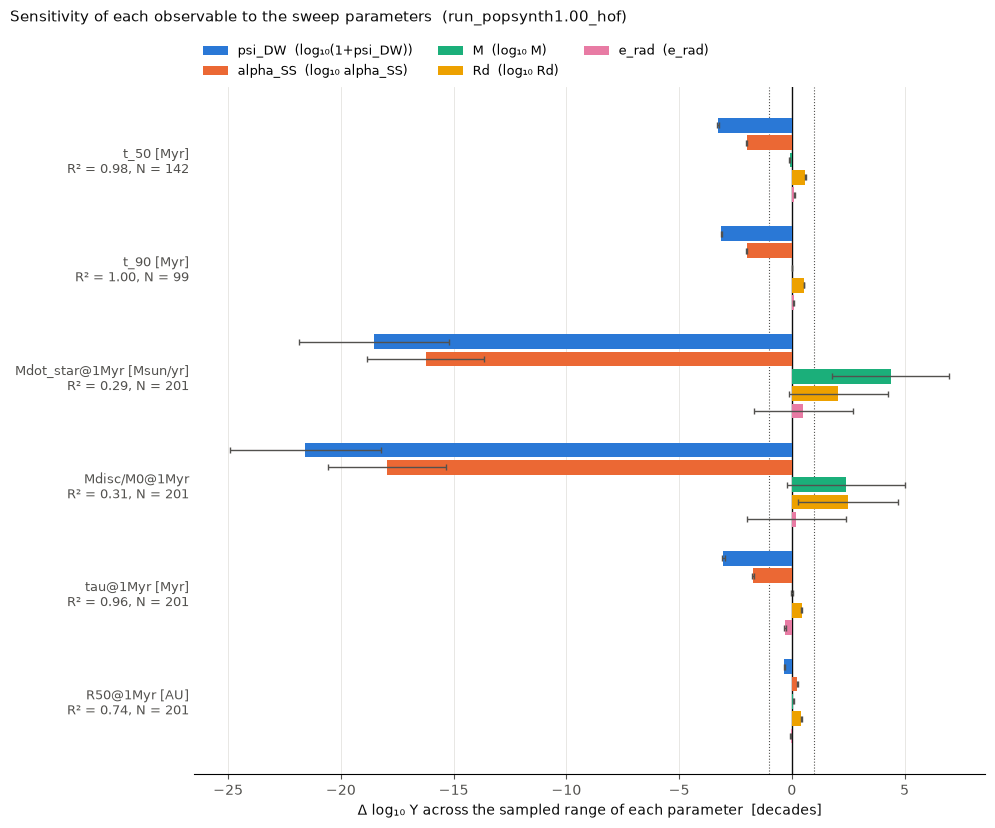

,observable,param,transform,beta,beta_se,R2,N
0,t_50 [Myr],psi_DW,log1p,-1.091,0.014,0.984,142
1,t_50 [Myr],alpha_SS,log,-1.004,0.014,0.984,142
2,t_50 [Myr],M,log,-0.043,0.011,0.984,142
3,t_50 [Myr],Rd,log,0.992,0.031,0.984,142
4,t_50 [Myr],e_rad,linear,0.524,0.095,0.984,142
5,t_90 [Myr],psi_DW,log1p,-1.043,0.004,0.999,99
6,t_90 [Myr],alpha_SS,log,-1.003,0.003,0.999,99
7,t_90 [Myr],M,log,-0.004,0.003,0.999,99
8,t_90 [Myr],Rd,log,0.889,0.008,0.999,99
9,t_90 [Myr],e_rad,linear,0.382,0.021,0.999,99


In [8]:
# ---- Figure 4: grouped horizontal bars -----------------------------------------------
# One group per observable (top to bottom in FIT_OBSERVABLES order), one bar per sweep
# parameter. Bar length = Delta log10 Y across that parameter's sampled range
# [decades of Y]; error bar = +-1 standard error. Grey dotted lines at +-1 = factor 10.
import matplotlib.pyplot as plt

SAVE_FIG4 = False                                     # True -> also write a PNG next to the CSVs
FIG4_PATH = os.path.join(STATUS_DIR, f"{SWEEP_NAME}_sensitivity.png")

# Categorical colours, assigned to parameters in FIXED sweep order (never by rank), so
# a parameter keeps its colour across figures and sweeps of the same layout. Reference
# palette slots 1-8 (dataviz skill, light mode); > 8 swept parameters would need faceting.
PARAM_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK_2, GRID_C = "#0b0b0b", "#52514e", "#e4e3df"   # text primary / secondary, gridlines

obs_order = [o for o in FIT_OBSERVABLES if o in set(fit_df["observable"])]
par_order = [p for p in SWEEP_PARAMS if p in USED_TRANSFORMS]
n_obs, n_par = len(obs_order), len(par_order)

group_h = 0.8                                         # height of one observable's group (1 = spacing)
bar_h = group_h / n_par
fig, ax = plt.subplots(figsize=(10, 0.22 * n_obs * n_par + 1.8))   # [inches]; height grows with #bars

for j, p in enumerate(par_order):
    d = fit_df[fit_df["param"] == p].set_index("observable").reindex(obs_order)
    # first parameter on top within each group
    y = np.arange(n_obs) - group_h / 2 + bar_h * (j + 0.5)
    label = f"{p}  ({_TRANSFORM_LABELS[USED_TRANSFORMS[p]].format(p=p)})"
    ax.barh(y, d["effect"], height=bar_h * 0.85,                # 0.85 -> small gap between bars
            color=PARAM_COLORS[j % len(PARAM_COLORS)], label=label, zorder=3)
    ax.errorbar(d["effect"], y, xerr=d["effect_se"], fmt="none",
                ecolor=INK_2, elinewidth=1, capsize=2, zorder=4)

ax.axvline(0, color=INK, lw=1, zorder=2)
for xv in (-1, 1):
    ax.axvline(xv, color=INK_2, lw=0.8, ls=":", zorder=1)       # +-1 decade = factor of 10

# y tick labels: observable name, plus fit quality underneath
r2n = fit_df.groupby("observable")[["R2", "N"]].first()
ax.set_yticks(np.arange(n_obs))
ax.set_yticklabels([f"{o}\nR² = {r2n.loc[o, 'R2']:.2f}, N = {r2n.loc[o, 'N']}" for o in obs_order],
                   color=INK, fontsize=9)
ax.invert_yaxis()                                     # first observable at the top
ax.set_xlabel("Δ log₁₀ Y across the sampled range of each parameter  [decades]", color=INK)
fig.suptitle(f"Sensitivity of each observable to the sweep parameters  ({SWEEP_NAME})",
             color=INK, fontsize=11, x=0.01, ha="left")
ax.grid(axis="x", color=GRID_C, lw=0.6, zorder=0)
ax.tick_params(colors=INK_2)
ax.tick_params(axis="y", length=0)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
# legend in one row above the plot, in sweep order (= top-to-bottom bar order in each group)
ax.legend(frameon=False, fontsize=9, ncol=min(n_par, 3), loc="lower left",
          bbox_to_anchor=(0.0, 1.0), borderaxespad=0.3)
fig.tight_layout()
if SAVE_FIG4:
    fig.savefig(FIG4_PATH, dpi=200, bbox_inches="tight")
    print("saved", FIG4_PATH)
plt.show()

# Raw coefficients (beta = power-law exponent for "log" parameters) for reference
fit_df.assign(beta=lambda d: d["beta"].round(3), beta_se=lambda d: d["beta_se"].round(3),
              R2=lambda d: d["R2"].round(3))[["observable", "param", "transform", "beta", "beta_se", "R2", "N"]]

# Figure 2: disc mass evolution, M_disc(t), on a grid of panels

A grid of panels of disc mass against time for a **slice** of the sweep:

* **fixed parameters** (`FIG2_FIXED`): every other sweep parameter is held at one value
  (default R_d = 50 AU, initial M = 0.01 M☉);
* **rows** (`FIG2_ROW_PARAM`, default `e_rad`) and **columns** (`FIG2_COL_PARAM`, default
  `alpha_SS`): one panel per combination (3 × 3 = 9 panels here);
* **lines** (`FIG2_LINE_PARAM`, default `psi_DW`): one line per value in every panel.

Every sweep parameter must be either fixed, a row, a column or the line parameter, so each
line is exactly one run. The cell stops with a message if one is left over (e.g. a future
sweep with an extra dimension: add it to `FIG2_FIXED`).

**Data:** `t` [yr → Myr] and `disk_Mass` [g → M☉] read from each run's .h5 file (the dense
series, one entry per 5 simulation steps). For plotting, each series is thinned to
`FIG2_MAX_POINTS` points evenly spaced in time, which looks the same at figure resolution.
`disk_Mass` is `disc.Mtot()`, the **total** (gas + dust) disc mass.

**Colours:** ψ is ordered (wind strength), so the ψ > 0 lines use one blue ramp, light → dark
for weak → strong wind. A line-parameter value of 0 (ψ = 0, pure viscous) is the reference
and is drawn as a **dashed neutral grey** line. (For a line parameter without a 0 value, every
value gets a blue step.)

**Runs that cannot be plotted:** a run with no evolution (`Mdot_out_of_range`, `missing`,
`unreadable`) has no line. Its panel lists it in the lower-left corner. `crashed` /
`incomplete` runs are drawn up to where they stopped, with an × at the last point.
Panels share both axes, so they can be compared directly. On the log axis the bottom is clipped at
`FIG2_Y_DECADES` decades below the largest initial mass, so a disc that drains away
runs off the bottom of the panel instead of squashing the other lines. Note that the ψ = 0 runs are
identical down a column (e_rad has no effect without a wind).

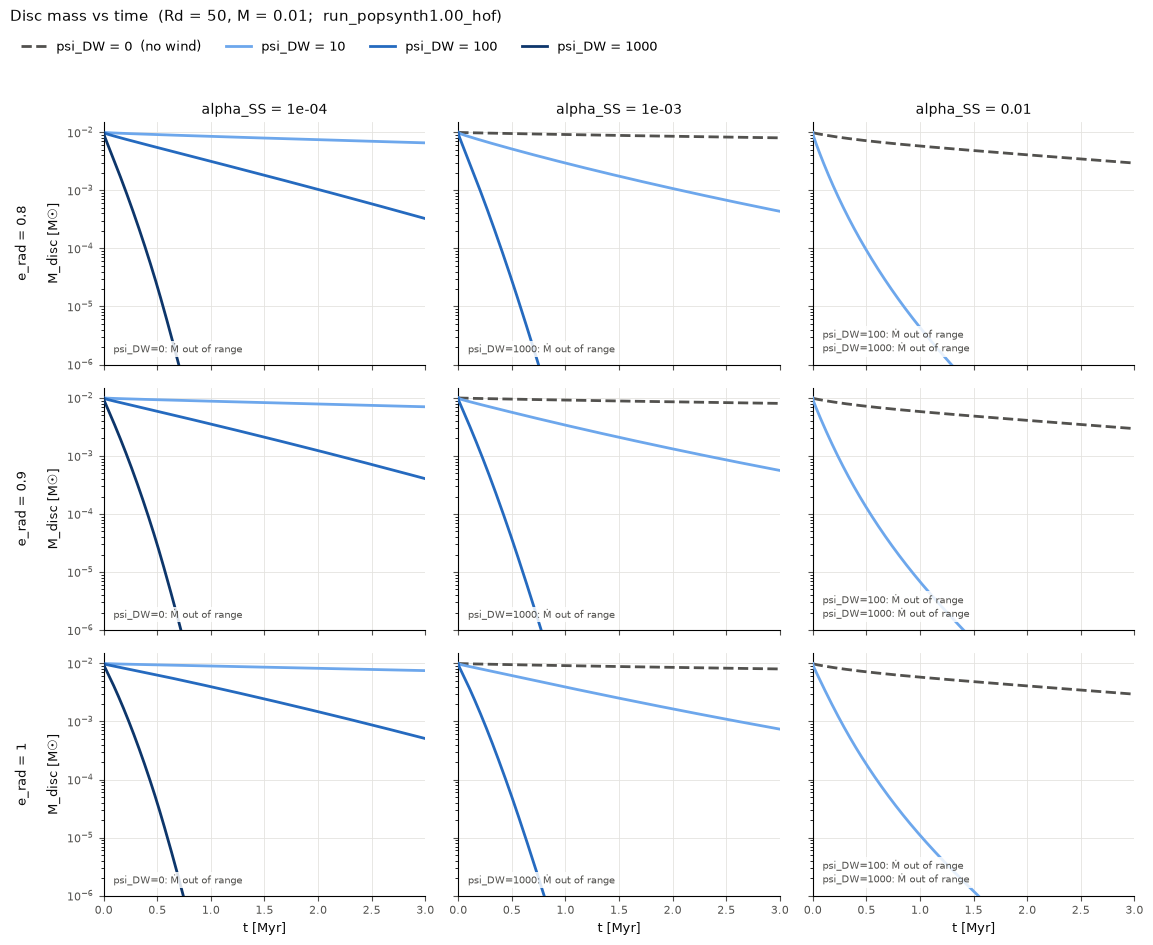

,filename,e_rad,alpha_SS,psi_DW,status
0,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0001,0.0,Mdot_out_of_range
1,hof_discwind_popsynth1.00_gamma1_psi10.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0001,10.0,complete
2,hof_discwind_popsynth1.00_gamma1_psi100.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0001,100.0,complete
3,hof_discwind_popsynth1.00_gamma1_psi1000.0_erad0.8_aSS1.0e-04_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0001,1000.0,complete
4,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-03_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0010,0.0,complete
5,hof_discwind_popsynth1.00_gamma1_psi10.0_erad0.8_aSS1.0e-03_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0010,10.0,complete
6,hof_discwind_popsynth1.00_gamma1_psi100.0_erad0.8_aSS1.0e-03_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0010,100.0,complete
7,hof_discwind_popsynth1.00_gamma1_psi1000.0_erad0.8_aSS1.0e-03_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0010,1000.0,Mdot_out_of_range
8,hof_discwind_popsynth1.00_gamma1_psi0.0_erad0.8_aSS1.0e-02_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0100,0.0,complete
9,hof_discwind_popsynth1.00_gamma1_psi10.0_erad0.8_aSS1.0e-02_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5,0.8,0.0100,10.0,complete


In [9]:
# ---- settings ------------------------------------------------------------------------
FIG2_FIXED      = {"Rd": 50.0, "M": 0.01}   # {sweep param: value}; Rd [AU], M [Msun] (initial disc mass)
FIG2_ROW_PARAM  = "e_rad"                   # varies down the rows    [dimensionless]
FIG2_COL_PARAM  = "alpha_SS"                # varies across columns   [dimensionless]
FIG2_LINE_PARAM = "psi_DW"                  # one coloured line per value [dimensionless]
FIG2_TMAX_MYR   = 3.0                       # [Myr] right edge of the time axis
FIG2_LOG_Y      = True                      # log M_disc axis (masses span decades)
FIG2_Y_DECADES  = 4                         # log axis: show this many decades below the largest
                                            # initial mass (a fully dispersed disc would otherwise
                                            # stretch the axis to ~1e-300 and squash every line)
FIG2_MAX_POINTS = 2000                      # points per plotted line after thinning
SAVE_FIG2 = False                           # True -> also write a PNG next to the CSVs
FIG2_PATH = os.path.join(STATUS_DIR, f"{SWEEP_NAME}_Mdisc_vs_t.png")

import matplotlib.pyplot as plt
from DiscEvolution.constants import Msun    # [g]

# ---- 1. select the runs --------------------------------------------------------------
placed = set(FIG2_FIXED) | {FIG2_ROW_PARAM, FIG2_COL_PARAM, FIG2_LINE_PARAM}
leftover = [p for p in SWEEP_PARAMS if p not in placed]
unknown = [p for p in placed if p not in SWEEP_PARAMS]
if leftover or unknown:
    raise ValueError(f"Every sweep parameter must be fixed, a row, a column or the line "
                     f"parameter. Not placed: {leftover}; not in this sweep: {unknown}. "
                     f"Sweep parameters: {SWEEP_PARAMS}")

sel = status_df.copy()
for p, v in FIG2_FIXED.items():
    sel = sel[np.isclose(sel[p].astype(float), float(v), rtol=1e-9)]   # float-safe ==
if sel.empty:
    raise ValueError(f"No run matches FIG2_FIXED = {FIG2_FIXED}. Sampled values: "
                     + "; ".join(f"{p}: {sorted(status_df[p].unique())}" for p in FIG2_FIXED))

row_vals  = sorted(sel[FIG2_ROW_PARAM].unique())
col_vals  = sorted(sel[FIG2_COL_PARAM].unique())
line_vals = sorted(sel[FIG2_LINE_PARAM].unique())


# ---- 2. colours and line styles for the line parameter ------------------------------
# Blue sequential ramp (dataviz reference palette, steps 300 / 500 / 700 ... light -> dark);
# a value of exactly 0 is the no-wind reference: neutral grey, dashed.
_BLUE_RAMP = ["#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]   # light -> dark
REF_GREY = "#52514e"
INK, INK_2, GRID_C = "#0b0b0b", "#52514e", "#e4e3df"   # text primary / secondary, gridlines

_pos = [v for v in line_vals if v != 0]
_ramp_idx = np.round(np.linspace(0, len(_BLUE_RAMP) - 1, len(_pos))).astype(int) if _pos else []
LINE_STYLE = {v: dict(color=_BLUE_RAMP[i], ls="-") for v, i in zip(_pos, _ramp_idx)}
if 0 in line_vals:
    LINE_STYLE[0] = dict(color=REF_GREY, ls="--")


def fmt_val(v):
    """Compact label for a parameter value: 0.0001 -> 1e-04, 10.0 -> 10, 0.9 -> 0.9."""
    v = float(v)
    return f"{v:.0e}" if (v != 0 and (abs(v) < 1e-2 or abs(v) >= 1e4)) else f"{v:g}"


def read_mass_series(path, tmax_myr=FIG2_TMAX_MYR, max_points=FIG2_MAX_POINTS):
    """(t [Myr], M_disc [Msun]) from one .h5 file, cut at tmax_myr and thinned to
    <= max_points points evenly spaced in time (always keeping the first and last point)."""
    with h5py.File(path, "r", locking=False) as f:
        t = f["t"][:] / 1e6                      # [yr] -> [Myr]
        M = f["disk_Mass"][:] / Msun             # [g]  -> [Msun]
    keep = t <= tmax_myr * (1 + 1e-9)
    t, M = t[keep], M[keep]
    if len(t) > max_points:
        idx = np.searchsorted(t, np.linspace(t[0], t[-1], max_points))
        idx = np.unique(np.clip(idx, 0, len(t) - 1))
        t, M = t[idx], M[idx]
    return t, M


# ---- 3. the figure -------------------------------------------------------------------
nrows, ncols = len(row_vals), len(col_vals)
M_top = 0.0                                       # [Msun], updated while plotting
fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols + 0.8, 2.8 * nrows + 1.2),
                         sharex=True, sharey=True, squeeze=False)
NO_LINE = {"Mdot_out_of_range": "Ṁ out of range", "missing": "missing", "unreadable": "unreadable"}

for i, rv in enumerate(row_vals):
    for j, cv in enumerate(col_vals):
        ax = axes[i, j]
        panel = sel[np.isclose(sel[FIG2_ROW_PARAM], rv) & np.isclose(sel[FIG2_COL_PARAM], cv)]
        notes = []                                # runs in this panel that have no line
        for lv in line_vals:
            run = panel[np.isclose(panel[FIG2_LINE_PARAM], lv)]
            if run.empty:
                notes.append(f"{FIG2_LINE_PARAM}={fmt_val(lv)}: not in sweep")
                continue
            run = run.iloc[0]
            if run["status"] in NO_LINE:
                notes.append(f"{FIG2_LINE_PARAM}={fmt_val(lv)}: {NO_LINE[run['status']]}")
                continue
            try:
                t, M = read_mass_series(os.path.join(OUTDIR, run["filename"]))
            except Exception as e:
                notes.append(f"{FIG2_LINE_PARAM}={fmt_val(lv)}: read error")
                print(f"read error {run['filename']}: {type(e).__name__}: {e}")
                continue
            ax.plot(t, M, lw=2, zorder=3, **LINE_STYLE[lv])
            M_top = max(M_top, M[0])              # [Msun] largest initial mass plotted (y-axis top)
            if run["status"] in ("crashed", "incomplete"):    # stopped early: mark where
                ax.plot(t[-1], M[-1], marker="x", ms=8, mew=2, color=LINE_STYLE[lv]["color"], zorder=4)
                notes.append(f"{FIG2_LINE_PARAM}={fmt_val(lv)}: {run['status']} (×)")
        if notes:
            ax.text(0.03, 0.04, "\n".join(notes), transform=ax.transAxes, fontsize=7.5,
                    color=INK_2, va="bottom", ha="left", zorder=5,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5))  # readable over lines
        # axes styling: recessive grid, no top/right spines
        ax.grid(color=GRID_C, lw=0.6, zorder=0)
        ax.tick_params(colors=INK_2, labelsize=8)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        if i == 0:
            ax.set_title(f"{FIG2_COL_PARAM} = {fmt_val(cv)}", color=INK, fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{FIG2_ROW_PARAM} = {fmt_val(rv)}\n\nM_disc [M☉]", color=INK, fontsize=9)
        if i == nrows - 1:
            ax.set_xlabel("t [Myr]", color=INK, fontsize=9)

axes[0, 0].set_xlim(0, FIG2_TMAX_MYR)
if FIG2_LOG_Y:
    axes[0, 0].set_yscale("log")
    if M_top > 0:                                 # shared y: setting one panel sets all
        axes[0, 0].set_ylim(M_top * 10.0 ** -FIG2_Y_DECADES, M_top * 1.5)   # [Msun]

# one shared legend for the line parameter (same colours in every panel)
handles = [plt.Line2D([], [], lw=2, **LINE_STYLE[lv]) for lv in line_vals]
labels = [f"{FIG2_LINE_PARAM} = {fmt_val(lv)}" + ("  (no wind)" if lv == 0 else "") for lv in line_vals]
fixed_txt = ", ".join(f"{p} = {fmt_val(v)}" for p, v in FIG2_FIXED.items())
fig.suptitle(f"Disc mass vs time  ({fixed_txt};  {SWEEP_NAME})", color=INK, fontsize=11,
             x=0.01, ha="left")
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.01, 0.96), ncol=len(line_vals),
           frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.93))
if SAVE_FIG2:
    fig.savefig(FIG2_PATH, dpi=200, bbox_inches="tight")
    print("saved", FIG2_PATH)
plt.show()

# table view: which run is in which panel, and its status
sel[["filename", FIG2_ROW_PARAM, FIG2_COL_PARAM, FIG2_LINE_PARAM, "status"]].sort_values(
    [FIG2_ROW_PARAM, FIG2_COL_PARAM, FIG2_LINE_PARAM]).reset_index(drop=True)